# 🎯 Resume ↔ Job Description Matcher

Match **multiple uploaded resumes** against every job posting in `job_dataset.csv` using classic, fast NLP:

| Component | Technique |
|---|---|
| Semantic text matching | **TF-IDF** vectorization + **Cosine Similarity** |
| Importance scoring | TF-IDF weights (rare, job-specific terms score higher) |
| **Keyword extraction** | Top TF-IDF terms extracted from each resume |
| **Skill matching** | Resume skills checked against each job's required skills/keywords |

**Speed:** the job TF-IDF matrix is built **once**; every resume then costs one sparse
transform + one vectorized cosine-similarity call → **milliseconds per resume**.

**How to add your resumes (any of these):**
1. Drop PDF / DOCX / TXT files into a `resumes/` folder next to this notebook, **or**
2. Use the interactive upload widget in section 4 (if `ipywidgets` is installed), **or**
3. Paste resume text into the `PASTE_RESUMES` dictionary.

If no resumes are supplied, 3 built-in demo resumes are used so the notebook runs end-to-end instantly.


In [1]:
import io
import os
import re
import time
import zipfile

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:  # rich display in Jupyter; plain print fallback elsewhere
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 220)

print("✅ Environment ready")

✅ Environment ready


## 1️⃣ Load the job dataset

In [2]:
CSV_PATH = "job_dataset.csv"

jobs = pd.read_csv(CSV_PATH)
jobs.columns = [c.strip() for c in jobs.columns]

# Guarantee every text column exists and has no NaN
for col in ["JobID", "Title", "ExperienceLevel", "YearsOfExperience",
            "Skills", "Responsibilities", "Keywords"]:
    if col not in jobs.columns:
        jobs[col] = ""
    jobs[col] = jobs[col].fillna("")

print(f"Loaded {len(jobs)} job postings across {jobs['Title'].nunique()} unique titles")
jobs.head(3)

Loaded 1068 job postings across 219 unique titles


,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
0,NET-F-001,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Framework; .NET Core fundamentals; ASP.NET; MVC; HTML; CSS; Ja...,Assist in coding and debugging applications; Learn and apply .NET Framework and Core f...,.NET; C#; ASP.NET MVC; Entity Framework; SQL Server; LINQ; Visual Studio; Unit Testing
1,NET-F-002,.NET Developer,Fresher,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTML; CSS; JavaScript basics; SQL Server; E...,Write simple C# programs under guidance; Support development of ASP.NET MVC applicatio...,.NET; C#; ASP.NET MVC; Entity Framework; SQL Server; Razor; Unit Testing
2,NET-F-003,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTML; CSS; JavaScript basics; SQL Server; Git,Contribute to development of small modules; Assist in bug fixing and debugging; Learn ...,.NET; C#; ASP.NET MVC; SQL Server; Entity Framework; Git


## 2️⃣ Text preprocessing & skill vocabulary

`clean_text()` lowercases and strips noise but **keeps skill-relevant symbols** so
`C++`, `C#` and `.NET` survive preprocessing. The skill vocabulary is harvested from
the `Skills` and `Keywords` columns of every posting.

In [3]:
def clean_text(text):
    """Lowercase, remove noise, keep skill symbols (+ # . -)."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\+\#\.\-\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def split_list(cell):
    """Split a ';'-separated skills/keywords cell into a clean list."""
    return [s.strip() for s in str(cell).split(";") if s.strip()]


# One searchable text blob per job
jobs["job_text"] = (
    jobs["Title"] + " " + jobs["Skills"] + " "
    + jobs["Responsibilities"] + " " + jobs["Keywords"]
).apply(clean_text)

# Skill vocabulary built from ALL postings
SKILL_VOCAB = sorted(
    {s for cell in pd.concat([jobs["Skills"], jobs["Keywords"]]) for s in split_list(cell)}
)
SKILL_LOOKUP = {clean_text(s): s for s in SKILL_VOCAB if clean_text(s)}

print(f"📚 Skill vocabulary: {len(SKILL_VOCAB)} unique skills/keywords")
print(", ".join(SKILL_VOCAB[:25]) + " ...")

📚 Skill vocabulary: 2570 unique skills/keywords
.NET, .NET Core, .NET Core basics, .NET Core fundamentals, .NET Framework, .NET Framework basics, 3D Design, 3D Design Basics, 3D Graphics, 3D Modeling, 3D modeling and animation expert, 3D modeling and graphics, 3D modeling basics, 3D modeling fundamentals, 3D modeling/animation advanced, 3D modeling/animation expert, A/B Testing, A/B testing, AI, AI Analytics, AI Dashboards, AI Design Tools, AI Ethics, AI Frameworks, AI Marketing Tools ...


## 3️⃣ TF-IDF vectorization of all jobs (built once → fast reuse)

In [4]:
# Token pattern keeps C++, C#, .NET, node.js etc. intact
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b[a-z][a-z0-9\+\#\.]{1,}\b",
    ngram_range=(1, 2),
    sublinear_tf=True,
)

JOB_MATRIX = tfidf.fit_transform(jobs["job_text"])   # <-- built ONCE

print(f"TF-IDF matrix: {JOB_MATRIX.shape[0]} jobs × {JOB_MATRIX.shape[1]} features")

TF-IDF matrix: 1068 jobs × 19120 features


## 4️⃣ Resume input — multiple resumes supported

**Option A – folder:** put your PDF / DOCX / TXT resumes in a `resumes/` folder next to this notebook.
**Option B – widget:** run the upload widget below, select multiple files, then **re-run the cell**.
**Option C – paste:** add entries to `PASTE_RESUMES = {"Candidate Name": "resume text..."}`.

Resumes are parsed with `pypdf` (PDF), the standard library (DOCX is unzipped, no extra
dependency needed) or plain text — all with graceful fallbacks.

In [5]:
def read_pdf(data):
    """Extract text from PDF bytes using pypdf (or PyPDF2)."""
    try:
        from pypdf import PdfReader
    except ImportError:
        try:
            from PyPDF2 import PdfReader
        except ImportError:
            print("⚠ pypdf not installed -> install with: pip install pypdf")
            return ""
    reader = PdfReader(io.BytesIO(data))
    return "\n".join((page.extract_text() or "") for page in reader.pages)


def read_docx(data):
    """Extract text from DOCX bytes with the standard library only."""
    with zipfile.ZipFile(io.BytesIO(data)) as z:
        xml = z.read("word/document.xml").decode("utf-8", "ignore")
    xml = re.sub(r"</w:p>", "\n", xml)          # paragraph breaks
    return re.sub(r"<[^>]+>", "", xml)           # strip XML tags


def read_any(filename, data):
    ext = os.path.splitext(filename)[1].lower()
    try:
        if ext == ".pdf":
            return read_pdf(data)
        if ext == ".docx":
            return read_docx(data)
        return data.decode("utf-8", "ignore")
    except Exception as exc:
        print(f"⚠ Could not read {filename}: {exc}")
        return ""


def load_resumes_from_folder(folder="resumes"):
    """Load every .pdf/.docx/.txt resume found in a folder."""
    loaded = {}
    if os.path.isdir(folder):
        for fname in sorted(os.listdir(folder)):
            path = os.path.join(folder, fname)
            if os.path.splitext(fname)[1].lower() in (".pdf", ".docx", ".txt"):
                with open(path, "rb") as fh:
                    text = read_any(fname, fh.read())
                if text.strip():
                    loaded[fname] = text
    return loaded


# ---- Option A: folder uploads ----
resumes = load_resumes_from_folder("resumes")
if resumes:
    print(f"📁 Loaded {len(resumes)} resume(s) from 'resumes/' folder")

# ---- Option B: interactive widget upload (multiple files) ----
try:
    import ipywidgets as widgets

    uploader = widgets.FileUpload(accept=".pdf,.docx,.txt", multiple=True)
    display(uploader)

    def grab_uploaded(uploader):
        """Supports ipywidgets 7 (list) and 8+ (dict) value formats."""
        got = {}
        if isinstance(uploader.value, dict):
            for fname, meta in uploader.value.items():
                got[fname] = read_any(fname, bytes(meta["content"]))
        elif isinstance(uploader.value, (list, tuple)):
            for f in uploader.value:
                got[f["name"]] = read_any(f["name"], bytes(f["content"]))
        return got

    # Re-run this cell AFTER selecting files to pick up the uploads
    resumes.update(grab_uploaded(uploader))
except ImportError:
    print("ℹ ipywidgets not installed -> widget upload skipped (folder/paste/demo still work)")

# ---- Option C: paste resume text directly ----
PASTE_RESUMES = {
    # "Jane Smith": "Jane Smith ... python, sql, tableau, power bi ..."
}
resumes.update({k: v for k, v in PASTE_RESUMES.items() if str(v).strip()})

# ---- Built-in demo resumes (used only if nothing else was supplied) ----
DEMO_RESUMES = {
    "demo_alexa_net_fresher.docx.txt": """Alexa Chen - Fresher .NET Developer
Skills: C#, ASP.NET MVC, Entity Framework, SQL Server, LINQ, HTML, CSS,
JavaScript, Git, Visual Studio, unit testing.
Projects: built a college ASP.NET MVC web app backed by SQL Server with
Entity Framework and LINQ queries; wrote unit tests; used Git for version control.""",
    "demo_rahul_ai_senior.docx.txt": """Rahul Mehta - Senior AI Engineer, 6 years experience
Skills: Python, TensorFlow, PyTorch, Keras, Scikit-learn, Hugging Face
Transformers, LLMs, NLP, Computer Vision, MLOps, CI/CD, Docker, Kubernetes,
AWS, Azure, Spark, Hadoop, model monitoring, SHAP.
Experience: led deployment of deep learning and NLP models in production,
built ML pipelines on cloud platforms, mentored junior engineers.""",
    "demo_sara_fullstack.docx.txt": """Sara Khan - Full Stack Developer, 3 years experience
Skills: HTML, CSS, JavaScript, React, Redux, Node.js, Express, Django,
Flask, MySQL, PostgreSQL, MongoDB, REST APIs, Git, Docker, CI/CD, AWS.
Experience: developed end-to-end web applications, designed RESTful APIs,
optimized databases, worked in Agile teams, mentored interns.""",
}

if not resumes:
    resumes = dict(DEMO_RESUMES)
    print("ℹ No resumes found -> using 3 built-in demo resumes")

print(f"✅ {len(resumes)} resume(s) ready: {', '.join(resumes)}")

ℹ ipywidgets not installed -> widget upload skipped (folder/paste/demo still work)
ℹ No resumes found -> using 3 built-in demo resumes
✅ 3 resume(s) ready: demo_alexa_net_fresher.docx.txt, demo_rahul_ai_senior.docx.txt, demo_sara_fullstack.docx.txt


## 5️⃣ Matching engine — cosine similarity + skill matching + keyword extraction

For each resume against each job:
- **TF-IDF %** = cosine similarity between the resume vector and the job vector (×100)
- **Skill %** = share of the job's required skills/keywords found in the resume
- **Match %** = final score, `60% TF-IDF + 40% skill match` (weights configurable)

In [6]:
def extract_skills(text):
    """Return the set of vocabulary skills present in a resume text."""
    low = " " + clean_text(text) + " "
    found = set()
    for norm, original in SKILL_LOOKUP.items():
        pattern = r"(?<![a-z0-9])" + re.escape(norm) + r"(?![a-z0-9])"
        if re.search(pattern, low):
            found.add(original)
    return found


def top_keywords(text, k=15):
    """Top-k TF-IDF keywords extracted from a resume (keyword extraction)."""
    vec = tfidf.transform([clean_text(text)])
    weights = vec.toarray()[0]
    features = np.asarray(tfidf.get_feature_names_out())
    order = weights.argsort()[::-1][:k]
    return [(features[i], round(float(weights[i]), 3)) for i in order if weights[i] > 0]


def match_resume(resume_text, top_n=10, w_tfidf=0.6, w_skill=0.4):
    """Rank ALL jobs for one resume. Fast: 1 transform + 1 vectorized cosine call."""
    t0 = time.perf_counter()
    sim = cosine_similarity(tfidf.transform([clean_text(resume_text)]), JOB_MATRIX)[0]
    resume_skills = extract_skills(resume_text)

    rows = []
    for i, row in jobs.iterrows():
        job_skills = set(split_list(row["Skills"]) + split_list(row["Keywords"]))
        matched = job_skills & resume_skills
        missing = sorted(job_skills - matched)
        skill_pct = 100 * len(matched) / len(job_skills) if job_skills else 0.0
        tfidf_pct = 100 * float(sim[i])
        final_pct = w_tfidf * tfidf_pct + w_skill * skill_pct
        rows.append({
            "Job ID": row["JobID"],
            "Title": row["Title"],
            "Level": row["ExperienceLevel"],
            "TF-IDF %": round(tfidf_pct, 1),
            "Skill %": round(skill_pct, 1),
            "Match %": round(final_pct, 1),
            "Matched Skills": ", ".join(sorted(matched)) if matched else "-",
            "Missing Skills": ", ".join(missing[:8]) + (" ..." if len(missing) > 8 else ""),
        })

    result = pd.DataFrame(rows).sort_values("Match %", ascending=False).head(top_n)
    result = result.reset_index(drop=True)
    result.insert(0, "Rank", result.index + 1)

    result.attrs["elapsed_ms"] = (time.perf_counter() - t0) * 1000
    result.attrs["keywords"] = top_keywords(resume_text)
    result.attrs["resume_skills"] = resume_skills
    return result


print("⚙ Matching engine ready")

⚙ Matching engine ready


## 6️⃣ Run matching for every uploaded resume

In [7]:
TOP_N = 10          # jobs to show per resume
W_TFIDF, W_SKILL = 0.6, 0.4   # weights for the final score

all_results = {}
t_start = time.perf_counter()

for name, text in resumes.items():
    print("=" * 110)
    print(f"📄 RESUME: {name}")
    result = match_resume(text, top_n=TOP_N, w_tfidf=W_TFIDF, w_skill=W_SKILL)
    all_results[name] = result

    print(f"⏱  Matched against {len(jobs)} jobs in {result.attrs['elapsed_ms']:.1f} ms")
    kws = ", ".join(k for k, _ in result.attrs["keywords"][:12])
    print(f"🔑 Extracted keywords: {kws}")
    skills = sorted(result.attrs["resume_skills"])
    print(f"🧠 Skills detected ({len(skills)}): {', '.join(skills) if skills else '-'}")
    display(result.style.hide(axis="index")
            if hasattr(result, "style") else result)

flat = pd.concat([df.assign(Resume=name) for name, df in all_results.items()])
flat.to_csv("resume_job_matches.csv", index=False)
print("=" * 110)
print(f"💾 Saved all results -> resume_job_matches.csv")
print(f"✅ Finished {len(all_results)} resume(s) × {len(jobs)} jobs in {time.perf_counter() - t_start:.2f} s total")

📄 RESUME: demo_alexa_net_fresher.docx.txt
⏱  Matched against 1068 jobs in 874.0 ms
🔑 Extracted keywords: linq, entity framework, entity, sql server, asp.net mvc, asp.net, mvc, framework, with entity, studio unit, for version, framework and
🧠 Skills detected (19): .NET, ASP.NET, ASP.NET MVC, C#, CSS, Entity Framework, Fresher, Git, HTML, HTML/CSS, JavaScript, LINQ, MVC, SQL, SQL Server, Testing, Unit Testing, Version Control, Visual Studio


,Rank,Job ID,Title,Level,TF-IDF %,Skill %,Match %,Matched Skills,Missing Skills
0,1,NET-F-001,.NET Developer,Fresher,51.7,68.4,58.4,".NET, ASP.NET, ASP.NET MVC, C#, CSS, Entity Framework, Git, HTML, LINQ, MVC, SQL Serve...",".NET Core fundamentals, .NET Framework, Entity Framework basics, JavaScript basics, Un..."
1,2,NET-F-008,.NET Developer,Fresher,46.8,75.0,58.1,".NET, ASP.NET MVC, C#, Entity Framework, LINQ, SQL Server",".NET Framework basics, Entity Framework basics"
2,3,NET-F-005,.NET Developer,Fresher,40.3,81.8,56.9,".NET, ASP.NET, ASP.NET MVC, C#, CSS, Entity Framework, HTML, MVC, SQL Server","Entity Framework basics, JavaScript basics"
3,4,NET-F-004,.NET Developer,Fresher,34.8,81.8,53.6,".NET, ASP.NET, C#, CSS, Entity Framework, HTML, LINQ, SQL Server, Visual Studio",".NET Framework, ASP.NET basics"
4,5,NET-F-010,.NET Developer,Fresher,37.2,75.0,52.3,".NET, ASP.NET MVC, C#, Entity Framework, Git, SQL Server",".NET Core basics, Entity Framework basics"
5,6,NET-F-007,.NET Developer,Fresher,27.7,77.8,47.7,".NET, ASP.NET MVC, C#, CSS, HTML, SQL Server, Visual Studio",".NET Core basics, VB.NET"
6,7,NET-F-009,.NET Developer,Fresher,21.9,85.7,47.4,".NET, ASP.NET, C#, CSS, HTML, SQL Server",.NET Framework
7,8,NET-F-003,.NET Developer,Fresher,30.3,72.7,47.3,".NET, ASP.NET MVC, C#, CSS, Entity Framework, Git, HTML, SQL Server",".NET Core, JavaScript basics, VB.NET basics"
8,9,NET-F-002,.NET Developer,Fresher,35.7,64.3,47.1,".NET, ASP.NET, ASP.NET MVC, C#, CSS, Entity Framework, HTML, SQL Server, Unit Testing",".NET Framework basics, Entity Framework basics, JavaScript basics, NUnit basics, Razor"
9,10,NET-F-006,.NET Developer,Fresher,20.2,66.7,38.8,".NET, ASP.NET, C#, Git, SQL Server, Unit Testing",".NET Framework, NUnit basics, Razor"


📄 RESUME: demo_rahul_ai_senior.docx.txt
⏱  Matched against 1068 jobs in 1532.1 ms
🔑 Extracted keywords: experience, nlp models, nlp, monitoring shap, models in, pipelines on, deployment of, and nlp, mlops ci, ml pipelines, model monitoring, learning and
🧠 Skills detected (29): AI, AWS, Azure, CI/CD, Cloud, Cloud Platforms, Computer vision, Deep Learning, Docker, Docker/Kubernetes, Hadoop, Hugging Face, Hugging Face Transformers, Keras, Kubernetes, LLMs, ML, ML Pipelines, MLOps, Model Monitoring, Monitoring, NLP, PyTorch, Python, SHAP, Scikit-learn, Senior, Spark, TensorFlow


,Rank,Job ID,Title,Level,TF-IDF %,Skill %,Match %,Matched Skills,Missing Skills
0,1,AI015,AI Engineer - Experienced,Senior-Level,48.3,72.4,58.0,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Keras, Kube...","C++, Computer Vision, GCP, Java, LIME, R, Reinforcement Learning, Senior-Level"
1,2,AI020,AI Engineer - Experienced,Senior-Level,45.9,70.0,55.6,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Keras, Kube...","C++, Computer Vision, GCP, Java, LIME, ONNX, R, Reinforcement Learning ..."
2,3,AI017,,Senior-Level,44.4,72.4,55.6,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Keras, Kube...","C++, Computer Vision, GCP, Java, LIME, R, Reinforcement Learning, Senior-Level"
3,4,AI012,AI Engineer - Experienced,Senior-Level,44.0,72.4,55.4,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face Transformers...","C++, Computer Vision, GCP, Java, LIME, R, Reinforcement Learning, Senior-Level"
4,5,AI011,AI Engineer - Experienced,Senior-Level,43.0,70.0,53.8,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face Transformers...","C++, Computer Vision, GCP, Generative AI, Java, LIME, ONNX, R ..."
5,6,AI010,AI Engineer - Experienced,Mid-Senior Level,46.2,64.5,53.5,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face Transformers...","Apache Spark, C++, Computer Vision, GCP, Generative AI, Java, LIME, Mid-Senior Level ..."
6,7,AI018,AI Engineer - Experienced,Senior-Level,40.5,72.4,53.3,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Keras, Kube...","C++, Computer Vision, GCP, Java, LIME, R, Reinforcement Learning, Senior-Level"
7,8,AI016,AI Engineer - Experienced,Senior-Level,41.4,70.0,52.8,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Keras, Kube...","C++, Computer Vision, GCP, Generative AI, Java, LIME, ONNX, R ..."
8,9,AI013,AI Engineer - Experienced,Senior-Level,41.1,69.0,52.3,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Kubernetes,...","C++, Computer Vision, GCP, Java, LIME, ONNX, R, Reinforcement Learning ..."
9,10,AI014,AI Engineer - Experienced,Senior-Level,38.3,70.0,51.0,"AI, AWS, Azure, CI/CD, Cloud, Deep Learning, Docker, Hadoop, Hugging Face, Keras, Kube...","C++, Computer Vision, GCP, Generative AI, Java, LIME, ONNX, R ..."


📄 RESUME: demo_sara_fullstack.docx.txt
⏱  Matched against 1068 jobs in 880.8 ms
🔑 Extracted keywords: experience, node.js express, express, mongodb rest, interns, end, end web, agile teams, apis git, react redux, cd aws, flask mysql
🧠 Skills detected (28): APIs, AWS, Agile, CI/CD, CSS, Django, Django/Flask, Docker, Docker, CI/CD, Express, Flask, Full Stack Developer, Git, HTML, HTML/CSS, JS, JavaScript, MongoDB, MySQL, MySQL/PostgreSQL, Node.js, PostgreSQL, REST APIs, RESTful APIs, React, React/Redux, Redux, Web Applications


,Rank,Job ID,Title,Level,TF-IDF %,Skill %,Match %,Matched Skills,Missing Skills
0,1,2,Full Stack Developer - Entry Level,Fresher,29.0,63.2,42.7,"Agile, CSS, Flask, Full Stack Developer, Git, HTML, JavaScript, MongoDB, MySQL, Node.j...","Angular, Backend, Entry-Level, Fresher, Frontend, Vue.js, Web Development"
1,2,12,Full Stack Developer - Experienced,Experienced,33.1,53.8,41.4,"Agile, CI/CD, CSS, Django, Docker, Flask, Full Stack Developer, Git, HTML, MongoDB, My...","Angular, Backend, Cloud Development, Cloud Platforms, Experienced, Frontend, JavaScrip..."
2,3,WEB-E-013,Web Developer,Experienced,17.7,70.0,38.6,"AWS, Docker, JavaScript, MongoDB, Node.js, REST APIs, React","Express.js, GraphQL, Kubernetes"
3,4,7,Full Stack Developer - Entry Level,Fresher,23.5,61.1,38.5,"Agile, CSS, Django, Full Stack Developer, Git, HTML, JavaScript, MongoDB, MySQL, Node....","Angular, Backend, Entry-Level, Fresher, Frontend, Vue.js, Web Development"
4,5,5,Full Stack Developer - Entry Level,Fresher,28.4,52.6,38.1,"Agile, CSS, Django, Flask, Full Stack Developer, Git, HTML, JavaScript, Node.js, React","Angular, Backend, Entry-Level, Fresher, Frontend, NoSQL, SQL, Vue.js ..."
5,6,16,Full Stack Developer - Experienced,Experienced,27.9,53.6,38.1,"Agile, CI/CD, CSS, Django, Docker, Flask, Full Stack Developer, Git, HTML, MongoDB, My...","Angular, Backend, Cloud, Cloud Platforms, Enterprise Applications, Experienced, Fronte..."
6,7,WEB-E-019,Web Developer,Experienced,16.7,70.0,38.0,"AWS, Docker, JavaScript, MongoDB, Node.js, REST APIs, React","Express.js, GraphQL, Kubernetes"
7,8,SE-E18,Software Engineer - Experienced,Experienced,17.9,66.7,37.4,"Agile, CSS, Git, HTML, JavaScript, REST APIs, React, Redux","Front-End, Mentoring, Software Engineer, Testing"
8,9,WEB-E-011,Web Developer,Experienced,17.6,66.7,37.2,"AWS, CI/CD, Docker, JavaScript, MongoDB, Node.js, REST APIs, React","Express.js, GraphQL, SQL, TypeScript"
9,10,15,Full Stack Developer - Experienced,Experienced,25.9,52.0,36.4,"Agile, CI/CD, Django, Docker, Flask, Full Stack Developer, Git, JavaScript, MongoDB, M...","Angular, Backend, CSS3, Cloud, Experienced, Frontend, HTML5, Kubernetes ..."


💾 Saved all results -> resume_job_matches.csv
✅ Finished 3 resume(s) × 1068 jobs in 3.47 s total


## 7️⃣ Visual summary — top 5 job matches per resume

C:\Users\Ahmad\AppData\Local\Temp\ipykernel_15716\1357134336.py:16: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ahmad\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


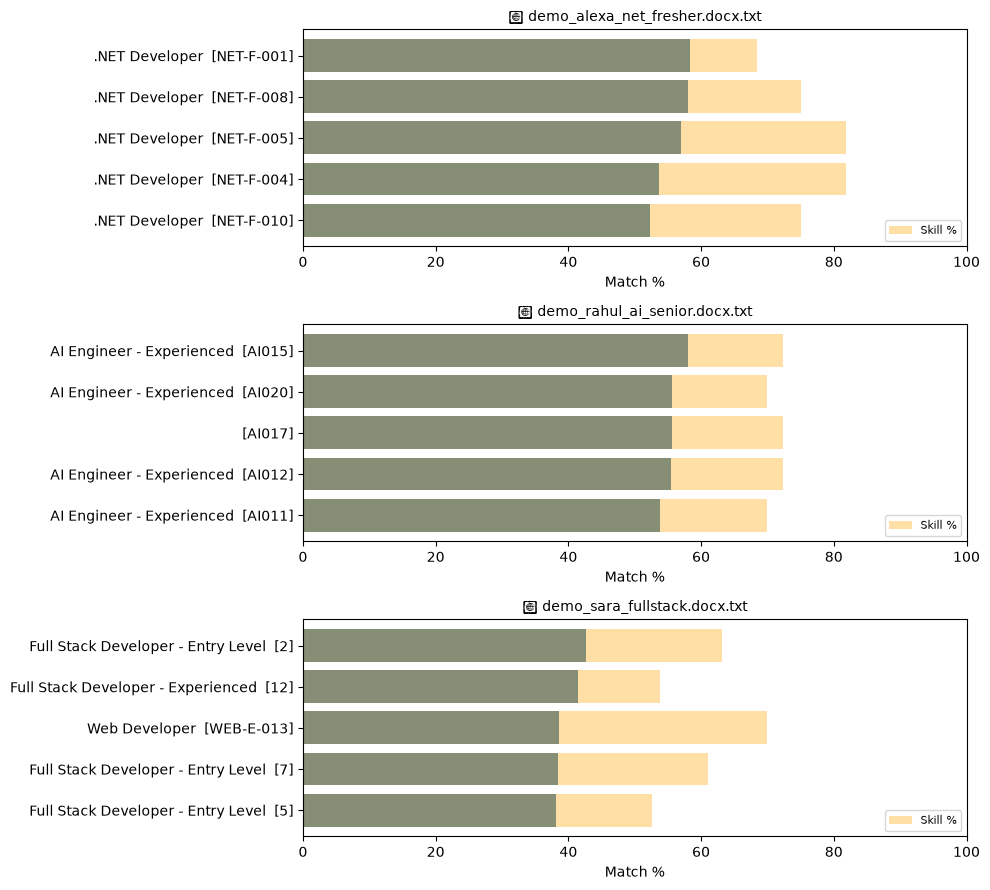

In [8]:
import matplotlib.pyplot as plt

n = len(all_results)
fig, axes = plt.subplots(n, 1, figsize=(10, max(3.0, 3.0 * n)), squeeze=False)

for ax, (name, result) in zip(axes.ravel(), all_results.items()):
    top = result.head(5).iloc[::-1]
    labels = top["Title"].fillna("Unknown") + "  [" + top["Job ID"].astype(str) + "]"
    ax.barh(labels, top["Match %"], color="steelblue")
    ax.barh(labels, top["Skill %"], color="orange", alpha=0.35, label="Skill %")
    ax.set_title(f"📄 {name}", fontsize=10)
    ax.set_xlabel("Match %")
    ax.set_xlim(0, 100)
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

---
### 📝 Notes
- **Match %** = `0.6 × TF-IDF cosine similarity + 0.4 × skill-match ratio` — tweak `W_TFIDF` / `W_SKILL` in section 6.
- Increase `TOP_N` to see more ranked jobs per resume.
- Add more resumes anytime: drop files into `resumes/`, use the widget, or extend `PASTE_RESUMES`, then re-run sections 4–6.
- All rankings are exported to **`resume_job_matches.csv`**.